<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/ArsenicSkinImageBD(CNN_%2B_TRANSFORMER).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATASET_DIR = '/content/drive/MyDrive/ArsenicSkinImageBD'

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [5]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 8145 images belonging to 2 classes.
Found 2035 images belonging to 2 classes.


In [6]:
NUM_CLASSES = train_generator.num_classes
print("Correct Classes:", NUM_CLASSES)

print("Class mapping:", train_generator.class_indices)

Correct Classes: 2
Class mapping: {'Augmented': 0, 'Original': 1}


In [7]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

In [8]:
def build_model(num_classes):

    inputs = layers.Input(shape=(224,224,3))

    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output

    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    patches = h * w

    x = layers.Reshape((patches, c))(x)

    pos = tf.range(start=0, limit=patches, delta=1)
    pos_emb = layers.Embedding(patches, c)(pos)
    x = x + pos_emb

    for _ in range(2):
        attn = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=c // 4
        )(x, x)

        x1 = layers.Add()([x, attn])
        x1 = layers.LayerNormalization()(x1)

        ffn = layers.Dense(c * 2, activation='gelu')(x1)
        ffn = layers.Dense(c)(ffn)

        x = layers.Add()([x1, ffn])
        x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_model(NUM_CLASSES)
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 32,949,586 (125.69 MB)

 Trainable params: 27,848,114 (106.23 MB)

 Non-trainable params: 5,101,472 (19.46 MB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
callbacks_list = [
    callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    ),

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_list
)

Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 5045s 20s/step - accuracy: 0.7681 - loss: 0.5016 - val_accuracy: 0.7533 - val_loss: 0.3854 - learning_rate: 3.0000e-04
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4470s 18s/step - accuracy: 0.8047 - loss: 0.3585 - val_accuracy: 0.7499 - val_loss: 0.3582 - learning_rate: 3.0000e-04
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4431s 17s/step - accuracy: 0.8242 - loss: 0.3082 - val_accuracy: 0.8983 - val_loss: 0.1991 - learning_rate: 3.0000e-04
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4432s 17s/step - accuracy: 0.8543 - loss: 0.2370 - val_accuracy: 0.9081 - val_loss: 0.2119 - learning_rate: 3.0000e-04
Epoch 5/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4428s 17s/step - accuracy: 0.8778 - loss: 0.2772 - val_accuracy: 0.8609 - val_loss: 0.2280 - learning_rate: 3.0000e-04
Epoch 6/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4416s 17s/step - accuracy: 0.8976 - loss: 0.2139 - val_accuracy: 0.8658 - val_loss: 0.3031 - learning_rate: 3.0000e-04
Epoch 7/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 4457s 

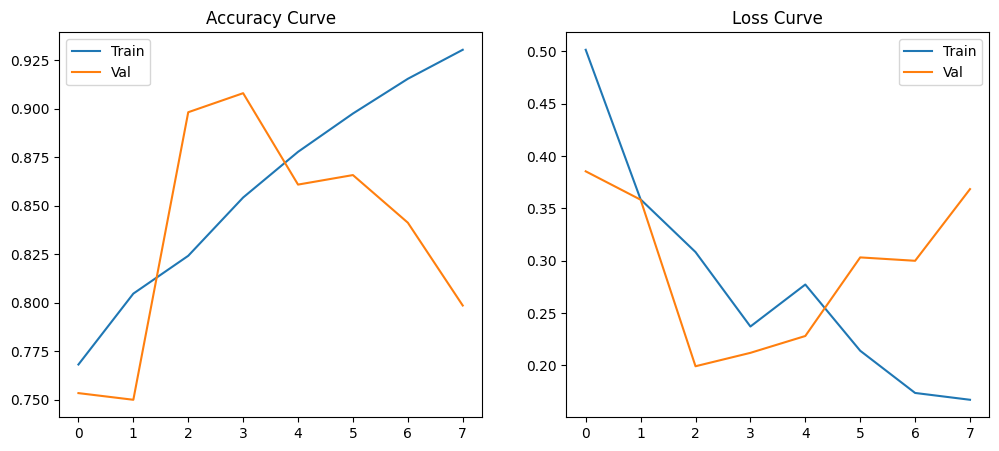

In [12]:
def plot_history(history):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title("Accuracy Curve")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title("Loss Curve")
    plt.legend()

    plt.show()

plot_history(history)

In [13]:
val_loss, val_acc = model.evaluate(val_generator)

print("=================================")
print("Final Validation Accuracy:", val_acc * 100)
print("=================================")

64/64 ━━━━━━━━━━━━━━━━━━━━ 343s 5s/step - accuracy: 0.8983 - loss: 0.1991
Final Validation Accuracy: 89.82800841331482


64/64 ━━━━━━━━━━━━━━━━━━━━ 358s 6s/step


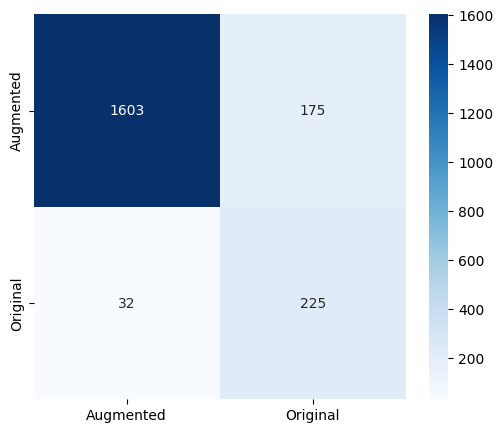

In [14]:
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.show()

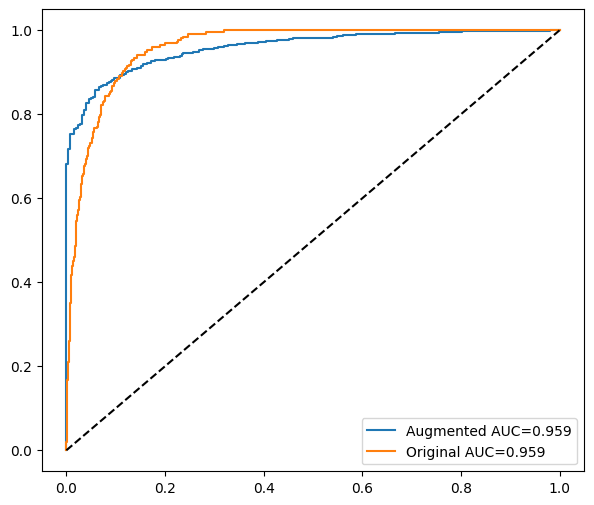

In [15]:
plt.figure(figsize=(7,6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true == i, Y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{labels[i]} AUC={auc_score:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()